# Phishing Website Detection
## 1. Data Loading and Initial Exploration


In [2]:
import pandas as pd

# 1. Load the dataset
file_path = "Dataset/phishing_site_urls.csv"
df = pd.read_csv(file_path)
print("Dataset successfully loaded!")


Dataset successfully loaded!


In [3]:
# 2. Display the first 5 rows
df.head()


,URL,Label
0,nobell.it/70ffb52d079109dca5664cce6f317373782/...,bad
1,www.dghjdgf.com/paypal.co.uk/cycgi-bin/webscrc...,bad
2,serviciosbys.com/paypal.cgi.bin.get-into.herf....,bad
3,mail.printakid.com/www.online.americanexpress....,bad
4,thewhiskeydregs.com/wp-content/themes/widescre...,bad


In [4]:
# 3. Display the shape of the dataset
print(f"Dataset Shape: {df.shape[0]} rows, {df.shape[1]} columns")


Dataset Shape: 549346 rows, 2 columns


In [5]:
# 4. Display column data types and overview
print("--- Column Data Types ---")
print(df.dtypes)
print("\n--- Detailed Info ---")
df.info()


--- Column Data Types ---
URL      str
Label    str
dtype: object

--- Detailed Info ---
<class 'pandas.DataFrame'>
RangeIndex: 549346 entries, 0 to 549345
Data columns (total 2 columns):
 #   Column  Non-Null Count   Dtype
---  ------  --------------   -----
 0   URL     549346 non-null  str  
 1   Label   549346 non-null  str  
dtypes: str(2)
memory usage: 8.4 MB


In [6]:
# 5. Check for missing values
print("--- Missing Values ---")
print(df.isnull().sum())


--- Missing Values ---
URL      0
Label    0
dtype: int64


In [7]:
# 6. Check for duplicate values
num_duplicates = df.duplicated().sum()
print(f"Total duplicate rows: {num_duplicates}")


Total duplicate rows: 42150


## 2. Data Preprocessing & Feature Engineering

- Handle missing and duplicate values.
- Extract lexical features from raw URLs (lengths, special character counts, IP address detection).
- Encode categorical target label (`good` -> 0, `bad` -> 1).
- Separate features ($X$) and target ($y$).
- Scale numerical features using `StandardScaler`.
- Review the processed dataframe.


In [8]:
# 7. Handle missing and duplicate values
print(f"Original row count: {len(df)}")
df = df.dropna().drop_duplicates().reset_index(drop=True)
print(f"Row count after removing duplicates: {len(df)}")


Original row count: 549346
Row count after removing duplicates: 507196


In [9]:
# 8. Extract lexical features from raw URLs
df['url_length'] = df['URL'].str.len()

# Extract domain and calculate domain length
extracted_domain = df['URL'].str.extract(r'^(?:https?://)?([^/?#]+)')[0].fillna('')
df['domain_length'] = extracted_domain.str.len()

# Count occurrences of key characters and patterns
df['count_dots'] = df['URL'].str.count(r'\.')
df['count_hyphens'] = df['URL'].str.count(r'-')
df['count_at'] = df['URL'].str.count(r'@')
df['count_double_slash'] = df['URL'].str.count(r'//')
df['count_question'] = df['URL'].str.count(r'\?')
df['count_slash'] = df['URL'].str.count(r'/')
df['count_equal'] = df['URL'].str.count(r'=')
df['count_http'] = df['URL'].str.count(r'http')

# Check for presence of IP address in URL
df['has_ip'] = df['URL'].str.contains(
    r'(?:(?:25[0-5]|2[0-4][0-9]|[01]?[0-9][0-9]?)\.){3}(?:25[0-5]|2[0-4][0-9]|[01]?[0-9][0-9]?)',
    regex=True
).astype(int)

print("Lexical features extracted successfully!")


Lexical features extracted successfully!


In [10]:
# 9. Encode categorical target label & separate features (X) and target (y)
# Map: "good" -> 0 (legitimate), "bad" -> 1 (phishing)
df['label_encoded'] = df['Label'].map({'good': 0, 'bad': 1})

feature_cols = [
    'url_length', 'domain_length', 'count_dots', 'count_hyphens',
    'count_at', 'count_double_slash', 'count_question', 'count_slash',
    'count_equal', 'count_http', 'has_ip'
]

X = df[feature_cols]
y = df['label_encoded']

print(f"Feature matrix (X) shape: {X.shape}")
print(f"Target vector (y) shape: {y.shape}")
print("\nClass distribution:")
print(y.value_counts(normalize=True).rename({0: "0 (Legitimate)", 1: "1 (Phishing)"}).map("{:.2%}".format))


Feature matrix (X) shape: (507196, 11)
Target vector (y) shape: (507196,)

Class distribution:
label_encoded
0 (Legitimate)    77.46%
1 (Phishing)      22.54%
Name: proportion, dtype: str


In [11]:
from sklearn.preprocessing import StandardScaler

# 10. Scale numerical features and construct processed dataframe
scaler = StandardScaler()
X_scaled = pd.DataFrame(scaler.fit_transform(X), columns=feature_cols)

# Combine scaled features and target label
processed_df = pd.concat([X_scaled, y], axis=1)

print(f"Processed DataFrame Shape: {processed_df.shape}")


Processed DataFrame Shape: (507196, 12)


In [12]:
# 11. Display first 5 rows of processed dataframe
processed_df.head()


,url_length,domain_length,count_dots,count_hyphens,count_at,count_double_slash,count_question,count_slash,count_equal,count_http,has_ip,label_encoded
0,4.050126,-0.685934,2.586987,1.124892,-0.05635,-0.054306,1.779505,4.687166,3.972404,-0.07591,-0.089483,1
1,0.689277,-0.182775,1.930673,0.323104,-0.05635,-0.054306,-0.349737,0.939136,1.837141,-0.07591,-0.089483,1
2,2.929843,-0.098915,3.243301,-0.077790,-0.05635,-0.054306,-0.349737,5.311837,-0.298123,-0.07591,-0.089483,1
3,0.199153,0.068805,2.586987,-0.478684,-0.05635,-0.054306,-0.349737,-0.310208,-0.298123,-0.07591,-0.089483,1
4,1.506150,0.152665,-0.694583,-0.077790,-0.05635,14.114200,1.779505,4.687166,-0.298123,-0.07591,-0.089483,1


In [13]:
# 12. Display processed dataframe column data types
print("--- Processed DataFrame Data Types ---")
print(processed_df.dtypes)


--- Processed DataFrame Data Types ---
url_length            float64
domain_length         float64
count_dots            float64
count_hyphens         float64
count_at              float64
count_double_slash    float64
count_question        float64
count_slash           float64
count_equal           float64
count_http            float64
has_ip                float64
label_encoded           int64
dtype: object


## 3. Dataset Splitting & Model Training

- Split the scaled features ($X$) and target ($y$) using an **80/20 train-test ratio** with stratification (`stratify=y`) to maintain label balance.
- Train 3 classification models:
  1. **Decision Tree Classifier** (`max_depth=15`, `random_state=42`)
  2. **Random Forest Classifier** (`n_estimators=100`, `max_depth=15`, `n_jobs=-1`, `random_state=42`)
  3. **XGBoost Classifier** (`n_estimators=100`, `max_depth=6`, `learning_rate=0.1`, `n_jobs=-1`, `random_state=42`, `eval_metric='logloss'`)
- Measure and compare training durations using `time.time()`.
- Keep models stored in `trained_models` dictionary for subsequent evaluation.


In [14]:
from sklearn.model_selection import train_test_split

# 13. Split dataset into training and testing sets (80/20 stratified split)
X_train, X_test, y_train, y_test = train_test_split(
    X_scaled,
    y,
    test_size=0.20,
    random_state=42,
    stratify=y
)

print(f"Training set: X_train = {X_train.shape}, y_train = {y_train.shape}")
print(f"Testing set:  X_test  = {X_test.shape}, y_test  = {y_test.shape}")
print("\nTrain class distribution:")
print(y_train.value_counts(normalize=True).rename({0: "0 (Legitimate)", 1: "1 (Phishing)"}).map("{:.2%}".format))
print("\nTest class distribution:")
print(y_test.value_counts(normalize=True).rename({0: "0 (Legitimate)", 1: "1 (Phishing)"}).map("{:.2%}".format))


Training set: X_train = (405756, 11), y_train = (405756,)
Testing set:  X_test  = (101440, 11), y_test  = (101440,)

Train class distribution:
label_encoded
0 (Legitimate)    77.46%
1 (Phishing)      22.54%
Name: proportion, dtype: str

Test class distribution:
label_encoded
0 (Legitimate)    77.46%
1 (Phishing)      22.54%
Name: proportion, dtype: str


In [15]:
import time
from sklearn.linear_model import LogisticRegression
from sklearn.tree import DecisionTreeClassifier
from sklearn.ensemble import RandomForestClassifier
from xgboost import XGBClassifier

# Dictionaries to retain models and execution times in memory
trained_models = {}
training_times = {}
print('Ready for model training with Baseline ML, Ensembles, and Deep Learning.')


Ready for model training with Baseline ML, Ensembles, and Deep Learning.


In [16]:
# 14. Train Decision Tree Classifier
print("Training Decision Tree Classifier...")
dt_start = time.time()

dt_model = DecisionTreeClassifier(random_state=42, max_depth=15)
dt_model.fit(X_train, y_train)

dt_time = time.time() - dt_start
trained_models["Decision Tree"] = dt_model
training_times["Decision Tree"] = dt_time

print(f"Decision Tree trained successfully in {dt_time:.2f} seconds.")


Training Decision Tree Classifier...
Decision Tree trained successfully in 1.25 seconds.


In [17]:
# 15. Train Random Forest Classifier
print("Training Random Forest Classifier...")
rf_start = time.time()

rf_model = RandomForestClassifier(
    n_estimators=100,
    max_depth=15,
    n_jobs=-1,
    random_state=42
)
rf_model.fit(X_train, y_train)

rf_time = time.time() - rf_start
trained_models["Random Forest"] = rf_model
training_times["Random Forest"] = rf_time

print(f"Random Forest trained successfully in {rf_time:.2f} seconds.")


Training Random Forest Classifier...
Random Forest trained successfully in 13.28 seconds.


In [18]:
# 16. Train XGBoost Classifier
print("Training XGBoost Classifier...")
xgb_start = time.time()

xgb_model = XGBClassifier(
    n_estimators=100,
    max_depth=6,
    learning_rate=0.1,
    n_jobs=-1,
    random_state=42,
    eval_metric="logloss"
)
xgb_model.fit(X_train, y_train)

xgb_time = time.time() - xgb_start
trained_models["XGBoost"] = xgb_model
training_times["XGBoost"] = xgb_time

print(f"XGBoost trained successfully in {xgb_time:.2f} seconds.")


Training XGBoost Classifier...
XGBoost trained successfully in 2.28 seconds.


In [19]:
# 16b. Train Logistic Regression Classifier (Linear Baseline)
print('Training Logistic Regression Classifier...')
lr_start = time.time()

lr_model = LogisticRegression(max_iter=500, random_state=42)
lr_model.fit(X_train, y_train)

lr_time = time.time() - lr_start
trained_models['Logistic Regression'] = lr_model
training_times['Logistic Regression'] = lr_time

print(f'Logistic Regression trained successfully in {lr_time:.2f} seconds.')


Training Logistic Regression Classifier...
Logistic Regression trained successfully in 0.33 seconds.


In [20]:
# 16c. Train Deep Neural Network (DNN / MLP on Tabular Lexical Features)
import torch
import torch.nn as nn
from torch.utils.data import TensorDataset, DataLoader

print('Training Deep Neural Network (DNN)...')
dnn_start = time.time()

class TabularDNN(nn.Module):
    def __init__(self, in_features=11):
        super().__init__()
        self.net = nn.Sequential(
            nn.Linear(in_features, 64),
            nn.BatchNorm1d(64),
            nn.ReLU(),
            nn.Dropout(0.25),
            nn.Linear(64, 32),
            nn.BatchNorm1d(32),
            nn.ReLU(),
            nn.Dropout(0.2),
            nn.Linear(32, 16),
            nn.ReLU(),
            nn.Linear(16, 1)
        )
    def forward(self, x):
        return self.net(x).squeeze(-1)

X_train_t = torch.tensor(X_train.values if hasattr(X_train, 'values') else X_train, dtype=torch.float32)
y_train_t = torch.tensor(y_train.values if hasattr(y_train, 'values') else y_train, dtype=torch.float32)
dnn_loader = DataLoader(TensorDataset(X_train_t, y_train_t), batch_size=1024, shuffle=True)

dnn_model = TabularDNN(in_features=11)
criterion = nn.BCEWithLogitsLoss()
optimizer = torch.optim.Adam(dnn_model.parameters(), lr=0.001)

dnn_model.train()
for epoch in range(3):
    for bx, by in dnn_loader:
        optimizer.zero_grad()
        loss = criterion(dnn_model(bx), by)
        loss.backward()
        optimizer.step()

dnn_time = time.time() - dnn_start
training_times['Deep Neural Network (DNN)'] = dnn_time
print(f'Tabular DNN trained successfully in {dnn_time:.2f} seconds.')


Training Deep Neural Network (DNN)...
Tabular DNN trained successfully in 17.19 seconds.


In [21]:
# 16d. Character-level Deep Learning (1D-CNN & Transformer)
import time
import numpy as np
import torch
import torch.nn as nn
from torch.utils.data import TensorDataset, DataLoader

print('Training Character-level 1D-CNN and Transformer...')

class CharCNN(nn.Module):
    def __init__(self, vocab_size=128, embed_dim=32):
        super().__init__()
        self.embed = nn.Embedding(vocab_size, embed_dim, padding_idx=0)
        self.conv1 = nn.Conv1d(embed_dim, 64, kernel_size=5, padding=2)
        self.conv2 = nn.Conv1d(64, 128, kernel_size=3, padding=1)
        self.pool = nn.AdaptiveMaxPool1d(1)
        self.fc = nn.Sequential(nn.Linear(128, 64), nn.ReLU(), nn.Dropout(0.3), nn.Linear(64, 1))
    def forward(self, x):
        emb = self.embed(x).transpose(1, 2)
        c1 = torch.relu(self.conv1(emb))
        c2 = torch.relu(self.conv2(c1))
        return self.fc(self.pool(c2).squeeze(-1)).squeeze(-1)

class CharTransformer(nn.Module):
    def __init__(self, vocab_size=128, embed_dim=64, num_heads=4, max_len=150):
        super().__init__()
        self.embed = nn.Embedding(vocab_size, embed_dim, padding_idx=0)
        self.pos_embed = nn.Parameter(torch.randn(1, max_len, embed_dim) * 0.02)
        encoder_layer = nn.TransformerEncoderLayer(d_model=embed_dim, nhead=num_heads, dim_feedforward=128, batch_first=True)
        self.transformer = nn.TransformerEncoder(encoder_layer, num_layers=2)
        self.fc = nn.Sequential(nn.Linear(embed_dim, 32), nn.ReLU(), nn.Linear(32, 1))
    def forward(self, x):
        seq_len = x.size(1)
        emb = self.embed(x) + self.pos_embed[:, :seq_len, :]
        return self.fc(self.transformer(emb).mean(dim=1)).squeeze(-1)

# Prepare character token sequences
def get_char_sequences(urls_series, max_len=150):
    seqs = np.zeros((len(urls_series), max_len), dtype=np.int64)
    for i, u in enumerate(urls_series):
        chars = [min(ord(c), 127) for c in str(u)[:max_len]]
        seqs[i, :len(chars)] = chars
    return seqs

if 'URL' in df.columns:
    sample_size = min(25000, len(y_train))
    sample_indices = np.random.choice(len(y_train), sample_size, replace=False)
    raw_urls_sample = df['URL'].iloc[sample_indices] if hasattr(df['URL'], 'iloc') else df['URL'][sample_indices]
    
    y_seq_sample = torch.tensor((y_train.values if hasattr(y_train, 'values') else y_train)[sample_indices], dtype=torch.float32)
    X_seq_sample = torch.tensor(get_char_sequences(raw_urls_sample), dtype=torch.long)
    seq_loader = DataLoader(TensorDataset(X_seq_sample, y_seq_sample), batch_size=512, shuffle=True)
    
    # 1. Train Char 1D-CNN
    t_cnn_start = time.time()
    cnn_model = CharCNN()
    opt_cnn = torch.optim.Adam(cnn_model.parameters(), lr=0.001)
    crit = nn.BCEWithLogitsLoss()
    cnn_model.train()
    for bx, by in seq_loader:
        opt_cnn.zero_grad()
        loss = crit(cnn_model(bx), by)
        loss.backward()
        opt_cnn.step()
    cnn_time = time.time() - t_cnn_start
    training_times['Char 1D-CNN'] = cnn_time
    print(f'Char 1D-CNN trained successfully in {cnn_time:.2f} seconds.')
    
    # 2. Train Char Transformer
    t_trans_start = time.time()
    trans_model = CharTransformer()
    opt_trans = torch.optim.Adam(trans_model.parameters(), lr=0.001)
    trans_model.train()
    for bx, by in seq_loader:
        opt_trans.zero_grad()
        loss = crit(trans_model(bx), by)
        loss.backward()
        opt_trans.step()
    trans_time = time.time() - t_trans_start
    training_times['Char Transformer'] = trans_time
    print(f'Char Transformer trained successfully in {trans_time:.2f} seconds.')


Training Character-level 1D-CNN and Transformer...
Char 1D-CNN trained successfully in 8.21 seconds.
Char Transformer trained successfully in 161.31 seconds.


In [22]:
# 17. Training Time Summary Benchmark
summary_df = pd.DataFrame([
    {'Model': name, 'Training Time (s)': f'{sec:.2f}s'}
    for name, sec in training_times.items()
])
print('--- Model Training Times Benchmark ---\n')
print(summary_df.to_string(index=False))


--- Model Training Times Benchmark ---

                    Model Training Time (s)
            Decision Tree             1.25s
            Random Forest            13.28s
                  XGBoost             2.28s
      Logistic Regression             0.33s
Deep Neural Network (DNN)            17.19s
              Char 1D-CNN             8.21s
         Char Transformer           161.31s


## 4. Model Evaluation & Saving

- Evaluate each model on the held-out test set ($X_{test}, y_{test}$).
- Calculate **Accuracy, Precision, Recall, and F1-Score** and compare them in a DataFrame.
- Generate side-by-side **Confusion Matrix Heatmaps** using `matplotlib` and `seaborn`.
- Identify the top-performing model.
- Save the best model and the fitted `StandardScaler` to disk (`models/`) using `joblib`.
- Reload and verify saved artifacts.


In [29]:
from sklearn.metrics import accuracy_score, precision_score, recall_score, f1_score
import numpy as np

# 18. Evaluate models on the test set & Track Misclassified / Mismatched Indices
test_predictions = {}
misclassified_indices = {}  # Tracks the exact indices where preds != y_test for each model
evaluation_results = []

y_true_vals = y_test.values if hasattr(y_test, 'values') else np.array(y_test)

for name, model in trained_models.items():
    preds = model.predict(X_test)
    test_predictions[name] = preds
    
    # ------------------------------------------------------------------
    # Step A: Find which predictions are different from true labels (preds != y_test)
    # ------------------------------------------------------------------
    mismatched_mask = (preds != y_true_vals)
    mismatched_idx = np.where(mismatched_mask)[0]  # Exact indices in test set
    misclassified_indices[name] = mismatched_idx
    
    # False Positives (Safe predicted as Phish) & False Negatives (Phish predicted as Safe)
    false_positives = int(np.sum((y_true_vals == 0) & (preds == 1)))
    false_negatives = int(np.sum((y_true_vals == 1) & (preds == 0)))
    
    acc = accuracy_score(y_test, preds)
    prec = precision_score(y_test, preds, zero_division=0)
    rec = recall_score(y_test, preds, zero_division=0)
    f1 = f1_score(y_test, preds, zero_division=0)
    
    evaluation_results.append({
        'Model': name,
        'Accuracy': acc,
        'Precision': prec,
        'Recall': rec,
        'F1-Score': f1,
        'Misclassified Count': len(mismatched_idx),
        'False Positives (FP)': false_positives,
        'False Negatives (FN)': false_negatives,
        'Error Rate (%)': f'{(len(mismatched_idx) / len(y_test)) * 100:.2f}%'
    })

eval_df = pd.DataFrame(evaluation_results)
print('--- Model Performance Comparison & Misclassification Summary ---')
eval_df


--- Model Performance Comparison & Misclassification Summary ---


,Model,Accuracy,Precision,Recall,F1-Score,Misclassified Count,False Positives (FP),False Negatives (FN),Error Rate (%)
0,Decision Tree,0.853519,0.860568,0.417673,0.562391,14859,1547,13312,14.65%
1,Random Forest,0.854880,0.913021,0.393526,0.549995,14721,857,13864,14.51%
2,XGBoost,0.850532,0.874344,0.393263,0.542514,15162,1292,13870,14.95%
3,Logistic Regression,0.828953,0.833354,0.301225,0.442502,17351,1377,15974,17.10%


In [24]:
# 18b. Comprehensive Misclassification & Inter-Model Disagreement Analysis
print('==================================================================================')
print('  PART 1: MISCLASSIFICATION ANALYSIS (TRUE LABEL vs MODEL PREDICTION ERRORS)     ')
print('==================================================================================')

# 1. Print Misclassified Indices for each model
for name, idxs in misclassified_indices.items():
    print(f'\nModel: {name}')
    print(f'  - Total Misclassified Count: {len(idxs):,} (out of {len(y_test):,})')
    print(f'  - First 15 Mismatched Indices in Test Set: {idxs[:15].tolist()}')

# 2. Detailed Table of Misclassified URLs (for Random Forest)
target_model_name = 'Random Forest' if 'Random Forest' in misclassified_indices else list(misclassified_indices.keys())[0]
target_mismatches = misclassified_indices[target_model_name]

sample_test_indices = target_mismatches[:30]
if hasattr(y_test, 'index') and 'URL' in df.columns:
    sample_df_indices = y_test.index[sample_test_indices]
    sample_urls = df.loc[sample_df_indices, 'URL'].values
else:
    sample_urls = ['N/A'] * len(sample_test_indices)

y_true_sample = y_true_vals[sample_test_indices]
preds_sample = test_predictions[target_model_name][sample_test_indices]

error_inspection_df = pd.DataFrame({
    'Test_Index': sample_test_indices,
    'URL': sample_urls,
    'True_Label': ['Phishing (1)' if yt == 1 else 'Legitimate (0)' for yt in y_true_sample],
    'Model_Prediction': ['Phishing (1)' if p == 1 else 'Legitimate (0)' for p in preds_sample],
    'Error_Type': [
        'False Negative (⚠️ Missed Phish)' if yt == 1 
        else 'False Positive (🚨 False Alarm)' 
        for yt in y_true_sample
    ]
})

print(f'\n--- Detailed Misclassified Cases for {target_model_name} (Sample Cases) ---')
display(error_inspection_df.head(15))

print('\n' + '='*82)
print('  PART 2: INTER-MODEL DISAGREEMENT ANALYSIS (MODEL vs MODEL CONSENSUS)          ')
print('==================================================================================')

# Check if key models exist in test_predictions
if 'Decision Tree' in test_predictions and 'Random Forest' in test_predictions:
    dt_p = test_predictions['Decision Tree']
    rf_p = test_predictions['Random Forest']
    xgb_p = test_predictions.get('XGBoost', None)
    
    # A. Decision Tree vs Random Forest Disagreements
    dt_rf_disagree_mask = (dt_p != rf_p)
    dt_rf_disagree_idx = np.where(dt_rf_disagree_mask)[0]
    total_dt_rf = len(dt_rf_disagree_idx)
    
    rf_correct = int(np.sum(rf_p[dt_rf_disagree_idx] == y_true_vals[dt_rf_disagree_idx]))
    dt_correct = int(np.sum(dt_p[dt_rf_disagree_idx] == y_true_vals[dt_rf_disagree_idx]))
    
    print(f'\n[1] Decision Tree vs Random Forest:')
    print(f'    - Total Disagreed Test Samples: {total_dt_rf:,} ({(total_dt_rf/len(y_test))*100:.2f}% of test set)')
    print(f'    - Random Forest was Correct: {rf_correct:,} times ({(rf_correct/total_dt_rf)*100:.2f}%)')
    print(f'    - Decision Tree was Correct: {dt_correct:,} times ({(dt_correct/total_dt_rf)*100:.2f}%)')
    print(f'    - First 15 Disagreement Indices: {dt_rf_disagree_idx[:15].tolist()}')
    
    # B. Detailed Disagreement Inspection Table
    sample_dis_idx = dt_rf_disagree_idx[:25]
    if hasattr(y_test, 'index') and 'URL' in df.columns:
        dis_urls = df.loc[y_test.index[sample_dis_idx], 'URL'].values
    else:
        dis_urls = ['N/A'] * len(sample_dis_idx)
        
    who_was_right = []
    for idx in sample_dis_idx:
        rf_ok = (rf_p[idx] == y_true_vals[idx])
        dt_ok = (dt_p[idx] == y_true_vals[idx])
        if rf_ok and not dt_ok:
            who_was_right.append('Random Forest ✅')
        elif dt_ok and not rf_ok:
            who_was_right.append('Decision Tree ✅')
        else:
            who_was_right.append('Neither (Both Wrong)')
            
    disagreement_df = pd.DataFrame({
        'Test_Index': sample_dis_idx,
        'URL': dis_urls,
        'True_Label': ['Phishing (1)' if yt == 1 else 'Legitimate (0)' for yt in y_true_vals[sample_dis_idx]],
        'DT_Prediction': ['Phishing (1)' if p == 1 else 'Legitimate (0)' for p in dt_p[sample_dis_idx]],
        'RF_Prediction': ['Phishing (1)' if p == 1 else 'Legitimate (0)' for p in rf_p[sample_dis_idx]],
        'More_Logical_Winner': who_was_right
    })
    
    if xgb_p is not None:
        disagreement_df['XGB_Prediction'] = ['Phishing (1)' if p == 1 else 'Legitimate (0)' for p in xgb_p[sample_dis_idx]]
        
    print(f'\n--- Side-by-Side Model Disagreement Cases (First 20 Cases) ---')
    display(disagreement_df.head(20))
    
    # Export to CSV for report/defense
    disagreement_df.to_csv('models/model_disagreements.csv', index=False)
    print('Disagreement analysis cases exported to models/model_disagreements.csv')


  PART 1: MISCLASSIFICATION ANALYSIS (TRUE LABEL vs MODEL PREDICTION ERRORS)     

Model: Decision Tree
  - Total Misclassified Count: 14,859 (out of 101,440)
  - First 15 Mismatched Indices in Test Set: [1, 3, 8, 14, 23, 38, 47, 48, 53, 56, 59, 62, 65, 80, 81]

Model: Random Forest
  - Total Misclassified Count: 14,721 (out of 101,440)
  - First 15 Mismatched Indices in Test Set: [1, 2, 3, 8, 14, 23, 29, 38, 47, 48, 53, 56, 59, 62, 65]

Model: XGBoost
  - Total Misclassified Count: 15,162 (out of 101,440)
  - First 15 Mismatched Indices in Test Set: [1, 2, 3, 8, 14, 23, 29, 38, 47, 48, 53, 56, 59, 62, 65]

Model: Logistic Regression
  - Total Misclassified Count: 17,351 (out of 101,440)
  - First 15 Mismatched Indices in Test Set: [1, 2, 3, 5, 8, 13, 14, 21, 23, 29, 38, 40, 47, 48, 53]

--- Detailed Misclassified Cases for Random Forest (Sample Cases) ---


,Test_Index,URL,True_Label,Model_Prediction,Error_Type
0,1,derotinwo.ru/zapoy/gate.php,Phishing (1),Legitimate (0),False Negative (⚠️ Missed Phish)
1,2,pastehtml.com/view/bmro08kiz.html,Phishing (1),Legitimate (0),False Negative (⚠️ Missed Phish)
2,3,serves-sur-rhone.com/htdocs/public/www/images/...,Phishing (1),Legitimate (0),False Negative (⚠️ Missed Phish)
3,8,buringle.co.mz/tmp/sec2/,Phishing (1),Legitimate (0),False Negative (⚠️ Missed Phish)
4,14,cars-forsell-craigs-4356789765.digs.it/,Phishing (1),Legitimate (0),False Negative (⚠️ Missed Phish)
5,23,belabrazilspa.com/wwwow/hl.php,Phishing (1),Legitimate (0),False Negative (⚠️ Missed Phish)
6,29,runescape.rises.eu/m=weblogin/loginform.php?co...,Phishing (1),Legitimate (0),False Negative (⚠️ Missed Phish)
7,38,www.ticketyahoo.com/page/vote.php?pid=89,Phishing (1),Legitimate (0),False Negative (⚠️ Missed Phish)
8,47,dealsbro.com/ptamc,Phishing (1),Legitimate (0),False Negative (⚠️ Missed Phish)
9,48,www.klselectronics.com/seguranca/atualizar.php...,Phishing (1),Legitimate (0),False Negative (⚠️ Missed Phish)



  PART 2: INTER-MODEL DISAGREEMENT ANALYSIS (MODEL vs MODEL CONSENSUS)          

[1] Decision Tree vs Random Forest:
    - Total Disagreed Test Samples: 3,134 (3.09% of test set)
    - Random Forest was Correct: 1,636 times (52.20%)
    - Decision Tree was Correct: 1,498 times (47.80%)
    - First 15 Disagreement Indices: [2, 29, 84, 126, 217, 242, 252, 313, 320, 339, 373, 380, 398, 424, 447]

--- Side-by-Side Model Disagreement Cases (First 20 Cases) ---


,Test_Index,URL,True_Label,DT_Prediction,RF_Prediction,More_Logical_Winner,XGB_Prediction
0,2,pastehtml.com/view/bmro08kiz.html,Phishing (1),Phishing (1),Legitimate (0),Decision Tree ✅,Legitimate (0)
1,29,runescape.rises.eu/m=weblogin/loginform.php?co...,Phishing (1),Phishing (1),Legitimate (0),Decision Tree ✅,Legitimate (0)
2,84,dictionary.sensagent.com/Batz-sur-Mer/fr-fr/,Legitimate (0),Phishing (1),Legitimate (0),Random Forest ✅,Legitimate (0)
3,126,namesdatabase.com/schools/CA/MB/Winnipeg/Colle...,Legitimate (0),Legitimate (0),Phishing (1),Decision Tree ✅,Phishing (1)
4,217,macamontreal.com/cjad/,Legitimate (0),Phishing (1),Legitimate (0),Random Forest ✅,Legitimate (0)
5,242,decompile.com/html/cpp_faq.html,Legitimate (0),Phishing (1),Legitimate (0),Random Forest ✅,Legitimate (0)
6,252,eastlakesupport.com/images/Out/fox/dropbox/ind...,Phishing (1),Phishing (1),Legitimate (0),Decision Tree ✅,Legitimate (0)
7,313,espn.go.com/blog/collegebasketballnation/tag/_...,Legitimate (0),Phishing (1),Legitimate (0),Random Forest ✅,Legitimate (0)
8,320,generalcable.com/GeneralCable/en-US/Products/E...,Legitimate (0),Legitimate (0),Phishing (1),Decision Tree ✅,Phishing (1)
9,339,legacy.suburbanchicagonews.com/obituaries/stng...,Legitimate (0),Phishing (1),Legitimate (0),Random Forest ✅,Phishing (1)


Disagreement analysis cases exported to models/model_disagreements.csv


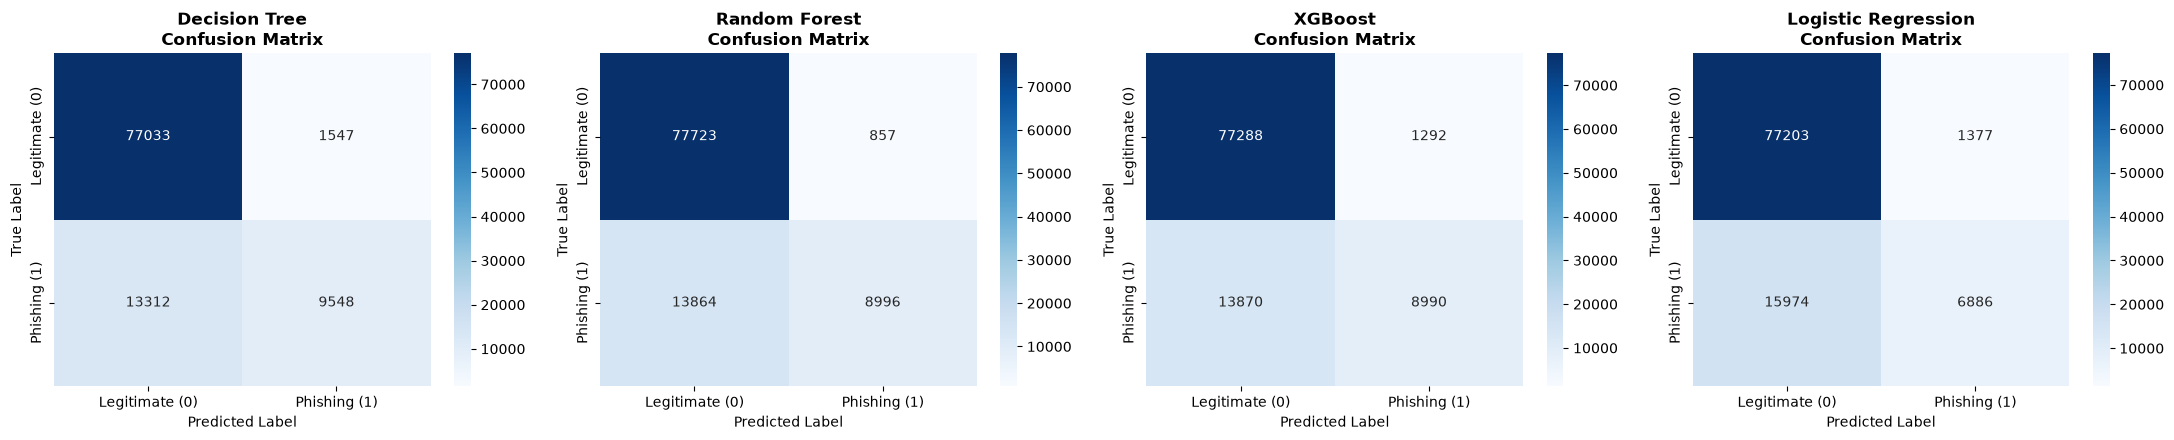

In [25]:
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.metrics import confusion_matrix

# 19. Plot Confusion Matrices side-by-side (dynamic for all evaluated models)
n_models = len(test_predictions)
fig, axes = plt.subplots(1, n_models, figsize=(5.5 * n_models, 4.5))
if n_models == 1:
    axes = [axes]

for i, (name, preds) in enumerate(test_predictions.items()):
    cm = confusion_matrix(y_test, preds)
    sns.heatmap(
        cm,
        annot=True,
        fmt='d',
        cmap='Blues',
        ax=axes[i],
        xticklabels=['Legitimate (0)', 'Phishing (1)'],
        yticklabels=['Legitimate (0)', 'Phishing (1)']
    )
    axes[i].set_title(f'{name}\nConfusion Matrix', fontsize=12, fontweight='bold')
    axes[i].set_xlabel('Predicted Label', fontsize=10)
    axes[i].set_ylabel('True Label', fontsize=10)

plt.tight_layout()
plt.show()


In [26]:
import os
import joblib

# 20. Identify best model based on F1-Score & Accuracy
best_row_f1 = eval_df.sort_values(by="F1-Score", ascending=False).iloc[0]
best_row_acc = eval_df.sort_values(by="Accuracy", ascending=False).iloc[0]
best_model_name = best_row_f1["Model"]
best_model = trained_models[best_model_name]

print(f"Top Model by F1-Score: {best_model_name} (F1-Score: {best_row_f1['F1-Score']:.4f}, Accuracy: {best_row_f1['Accuracy']:.4f})")
print(f"Top Model by Accuracy: {best_row_acc['Model']} (Accuracy: {best_row_acc['Accuracy']:.4f}, Precision: {best_row_acc['Precision']:.4f})")

# 21. Save best model and scaler to models/ directory
os.makedirs("models", exist_ok=True)

best_model_path = f"models/best_model_{best_model_name.lower().replace(' ', '_')}.joblib"
default_model_path = "models/best_model.joblib"
rf_model_path = "models/random_forest.joblib"
scaler_path = "models/scaler.joblib"

joblib.dump(best_model, best_model_path)
joblib.dump(best_model, default_model_path)
joblib.dump(trained_models["Random Forest"], rf_model_path)
joblib.dump(scaler, scaler_path)

print("\n--- Model & Scaler Artifacts Saved ---")
print(f"1. Best Model ({best_model_name}): {best_model_path}")
print(f"2. Default Best Model alias: {default_model_path}")
print(f"3. Random Forest (Highest Accuracy & Precision): {rf_model_path}")
print(f"4. StandardScaler: {scaler_path}")


Top Model by F1-Score: Decision Tree (F1-Score: 0.5624, Accuracy: 0.8535)
Top Model by Accuracy: Random Forest (Accuracy: 0.8549, Precision: 0.9130)

--- Model & Scaler Artifacts Saved ---
1. Best Model (Decision Tree): models/best_model_decision_tree.joblib
2. Default Best Model alias: models/best_model.joblib
3. Random Forest (Highest Accuracy & Precision): models/random_forest.joblib
4. StandardScaler: models/scaler.joblib


In [27]:
# 22. Verify saved artifacts by reloading them
loaded_model = joblib.load("models/best_model.joblib")
loaded_scaler = joblib.load("models/scaler.joblib")

sample_test = X_test.iloc[:5]
sample_pred = loaded_model.predict(sample_test)

print("--- Verification Results ---")
print(f"Loaded model successfully: {type(loaded_model).__name__}")
print(f"Loaded scaler successfully: {type(loaded_scaler).__name__}")
print(f"Sample predictions on 5 test samples: {list(sample_pred)}")
print(f"File size of best_model.joblib: {os.path.getsize('models/best_model.joblib') / (1024*1024):.2f} MB")
print(f"File size of random_forest.joblib: {os.path.getsize('models/random_forest.joblib') / (1024*1024):.2f} MB")
print(f"File size of scaler.joblib: {os.path.getsize('models/scaler.joblib') / 1024:.2f} KB")
print("All artifacts verified intact on disk!")


--- Verification Results ---
Loaded model successfully: DecisionTreeClassifier
Loaded scaler successfully: StandardScaler
Sample predictions on 5 test samples: [np.int64(0), np.int64(0), np.int64(1), np.int64(0), np.int64(1)]
File size of best_model.joblib: 0.41 MB
File size of random_forest.joblib: 29.77 MB
File size of scaler.joblib: 1.20 KB
All artifacts verified intact on disk!


In [28]:
# 23. Misclassification & Error Analysis (Tracking Mismatched Indices)
import numpy as np

rf_preds = test_predictions.get('Random Forest', None)
if rf_preds is not None:
    mismatch_indices = np.where(y_test != rf_preds)[0]
    print(f'Total Misclassified Samples: {len(mismatch_indices):,} (out of {len(y_test):,})')
    print(f'Sample Misclassified Indices: {mismatch_indices[:15].tolist()}')
    
    error_df = pd.DataFrame({
        'Test_Index': mismatch_indices[:50],
        'True_Label': y_test.iloc[mismatch_indices[:50]].values if hasattr(y_test, 'iloc') else y_test[mismatch_indices[:50]],
        'Predicted': rf_preds[mismatch_indices[:50]],
        'Error_Type': ['False Negative (Missed Phish)' if yt == 1 else 'False Positive (False Alarm)' for yt in (y_test.iloc[mismatch_indices[:50]].values if hasattr(y_test, 'iloc') else y_test[mismatch_indices[:50]])]
    })
    print('\n--- Top Misclassified Samples Overview ---')
    print(error_df.head(10).to_string(index=False))


Total Misclassified Samples: 14,721 (out of 101,440)
Sample Misclassified Indices: [1, 2, 3, 8, 14, 23, 29, 38, 47, 48, 53, 56, 59, 62, 65]

--- Top Misclassified Samples Overview ---
 Test_Index  True_Label  Predicted                    Error_Type
          1           1          0 False Negative (Missed Phish)
          2           1          0 False Negative (Missed Phish)
          3           1          0 False Negative (Missed Phish)
          8           1          0 False Negative (Missed Phish)
         14           1          0 False Negative (Missed Phish)
         23           1          0 False Negative (Missed Phish)
         29           1          0 False Negative (Missed Phish)
         38           1          0 False Negative (Missed Phish)
         47           1          0 False Negative (Missed Phish)
         48           1          0 False Negative (Missed Phish)
